Hämtar pandas för att läsa, hantera och analysera dataset. 
Hämtar matplotlib för att skapa grafer och visualiseringar. 

In [2]:
import pandas as pd # hämta pandas bibliotek för att hantera data
import matplotlib.pyplot as plt 


In [3]:
print("EDA Ghalia starter")

EDA Ghalia starter


Hämtar filmdata från API, ansluter till API och hämtar 100 populära filmer.

In [4]:
import sys
sys.path.append('/Users/ghaliaghazal/Documents/Grupp7_Datavisualisering_DE_UX')


from src.etl.extract import Extract

extractor = Extract()
data = extractor.fetch_movies()

len(data) # räknar hur många filmer som hämtades
data[0]

Fetching pages: 25/25 | Movies: 500 | Time: 9.7s


{'adult': False,
 'backdrop_path': '/zMwhWailP1WY7sb6AoE6b8ugoy.jpg',
 'genre_ids': [12, 16, 10751, 14],
 'id': 1007757,
 'title': 'Swapped',
 'original_language': 'en',
 'original_title': 'Swapped',
 'overview': 'A small woodland creature and a majestic bird, two natural sworn enemies of the Valley, magically trade places and set off on an adventure of a lifetime to switch back. Their journey soon uncovers a greater threat—one that could endanger not only their species, but the entire valley they call home.',
 'popularity': 169.7793,
 'poster_path': '/tHhxWxge06goXU6ZQH1hj7vK8Hd.jpg',
 'release_date': '2026-05-01',
 'softcore': False,
 'video': False,
 'vote_average': 9.0,
 'vote_count': 1689}

In [5]:
len(data)

500

In [6]:
df = pd.DataFrame(data) # gör om listan med 100 filmer som en tabell
df .head() # visar de 5 första filmerna i tabellen


,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
0,False,/zMwhWailP1WY7sb6AoE6b8ugoy.jpg,"[12, 16, 10751, 14]",1007757,Swapped,en,Swapped,"A small woodland creature and a majestic bird,...",169.7793,/tHhxWxge06goXU6ZQH1hj7vK8Hd.jpg,2026-05-01,False,False,9.000,1689
1,False,/dyJvKsNs2KP8qQnAXbRwDjblViy.jpg,"[16, 10751, 14]",129,Spirited Away,ja,千と千尋の神隠し,"A young girl, Chihiro, becomes trapped in a st...",30.3080,/39wmItIWsg5sZMyRUHLkWBcuVCM.jpg,2001-07-20,False,False,8.535,18405
2,False,/b6HWTOxn1xevvyHU2K9ICvaRU6g.jpg,"[14, 18, 80]",497,The Green Mile,en,The Green Mile,A supernatural tale set on death row in a Sout...,24.4261,/8VG8fDNiy50H4FedGwdSVUPoaJe.jpg,1999-12-10,False,False,8.507,19329
3,False,/2u7zbn8EudG6kLlBzUYqP8RyFU4.jpg,"[12, 14, 28]",122,The Lord of the Rings: The Return of the King,en,The Lord of the Rings: The Return of the King,As armies mass for a final battle that will de...,40.3914,/rCzpDGLbOoPwLjy3OAm5NUPOTrC.jpg,2003-12-17,False,False,8.500,26645
4,False,/oiwc338EoBgS4sEI2ixAny4KQKg.jpg,"[12, 14, 28]",120,The Lord of the Rings: The Fellowship of the Ring,en,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",35.7741,/6oom5QYQ2yQTMJIbnvbkBL9cHo6.jpg,2001-12-18,False,False,8.435,27659


# Connect and query
Hämtar data från databasen, ansluter till DuckDB och hämtar alla filmer som en tabell.

In [7]:
import duckdb
# anslut till databasen
con = duckdb.connect('/Users/ghaliaghazal/Documents/Grupp7_Datavisualisering_DE_UX/data/db/movies.duckdb')
# hämta alla filmer som en tabell
df = con.execute("SELECT * FROM movies").df()
df.head()

,movie_id,title,release_date,rating,popularity,release_year
0,83533,Avatar: Fire and Ash,2025-12-17,7.373,485.097198,2025
1,1226863,The Super Mario Galaxy Movie,2026-04-01,6.953,317.093903,2026
2,502356,The Super Mario Bros. Movie,2023-04-05,7.587,225.702698,2023
3,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.670,120.484398,2025
4,1159831,The Bride!,2026-03-04,6.300,91.137100,2026


## Utforska datan

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   movie_id      200 non-null    int32         
 1   title         200 non-null    str           
 2   release_date  200 non-null    datetime64[us]
 3   rating        200 non-null    float32       
 4   popularity    200 non-null    float32       
 5   release_year  200 non-null    int32         
dtypes: datetime64[us](1), float32(2), int32(2), str(1)
memory usage: 6.4 KB


In [9]:
df.describe()

,movie_id,release_date,rating,popularity,release_year
count,2.000000e+02,200,200.000000,200.000000,200.00000
mean,4.765350e+05,2014-01-31 07:55:12,7.130065,32.751999,2013.49000
min,2.200000e+01,1939-08-15 00:00:00,0.000000,7.884100,1939.00000
25%,2.012750e+03,2005-11-16 00:00:00,6.799750,13.302875,2005.00000
50%,2.886095e+05,2017-05-30 00:00:00,7.369500,16.726250,2017.00000
75%,9.832312e+05,2025-06-06 00:00:00,7.856250,23.900275,2025.00000
max,1.575337e+06,2026-11-08 00:00:00,8.534000,663.593689,2026.00000
std,5.226648e+05,NaN,1.377572,69.740295,14.47333


In [10]:
df.describe().round(2)

,movie_id,release_date,rating,popularity,release_year
count,200.00,200,200.00,200.00,200.00
mean,476535.01,2014-01-31 07:55:12,7.13,32.75,2013.49
min,22.00,1939-08-15 00:00:00,0.00,7.88,1939.00
25%,2012.75,2005-11-16 00:00:00,6.80,13.30,2005.00
50%,288609.50,2017-05-30 00:00:00,7.37,16.73,2017.00
75%,983231.25,2025-06-06 00:00:00,7.86,23.90,2025.00
max,1575337.00,2026-11-08 00:00:00,8.53,663.59,2026.00
std,522664.77,NaN,1.38,69.74,14.47


In [11]:
df.isnull() # visa om det finns några tomma värden i varje kolumn 

,movie_id,title,release_date,rating,popularity,release_year
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [12]:
df.isnull() .sum()

movie_id        0
title           0
release_date    0
rating          0
popularity      0
release_year    0
dtype: int64

## Analysera datan

In [13]:
df.sort_values('rating', ascending=False).head(10) # visa de 10 filmer med högst betyg

,movie_id,title,release_date,rating,popularity,release_year
114,129,Spirited Away,2001-07-20,8.534,29.763700,2001
16,129,Spirited Away,2001-07-20,8.533,38.416100,2001
25,497,The Green Mile,1999-12-10,8.505,28.282101,1999
122,497,The Green Mile,1999-12-10,8.505,22.583799,1999
68,1144107,The Legend of Hei 2,2025-07-18,8.500,13.672700,2025
154,1575337,Cosmic Princess Kaguya!,2026-01-22,8.500,13.456100,2026
169,1144107,The Legend of Hei 2,2025-07-18,8.500,11.205900,2025
22,122,The Lord of the Rings: The Return of the King,2003-12-17,8.496,27.986700,2003
118,122,The Lord of the Rings: The Return of the King,2003-12-17,8.496,25.522800,2003
31,1575337,Cosmic Princess Kaguya!,2026-01-22,8.438,21.922701,2026


In [15]:
df.sort_values('popularity', ascending=False).head(10)  # visa de 10 filmer som är mest populära
pop.head(10)

NameError: name 'pop' is not defined

In [16]:
df.title.head(10)

0                              Avatar: Fire and Ash
1                      The Super Mario Galaxy Movie
2                       The Super Mario Bros. Movie
3    Demon Slayer: Kimetsu no Yaiba Infinity Castle
4                                        The Bride!
5                         JUJUTSU KAISEN: Execution
6                                KPop Demon Hunters
7                                           Dracula
8       The SpongeBob Movie: Search for SquarePants
9                                      Blind Vaysha
Name: title, dtype: str

In [17]:
df[df['title'] == 'The Super Mario Galaxy Movie']

,movie_id,title,release_date,rating,popularity,release_year
1,1226863,The Super Mario Galaxy Movie,2026-04-01,6.953,317.093903,2026
100,1226863,The Super Mario Galaxy Movie,2026-04-01,6.799,663.593689,2026


## Visualisera 

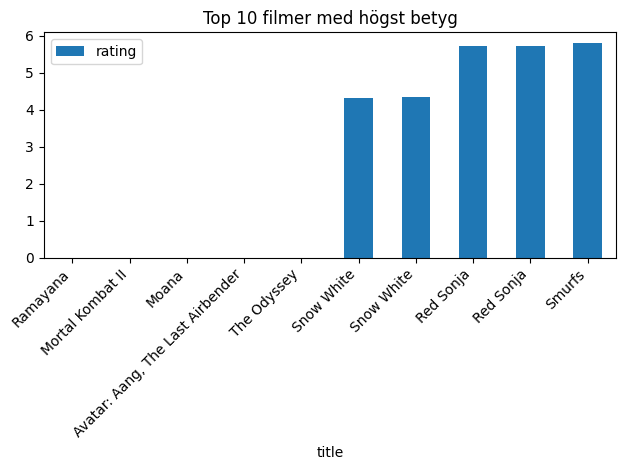

In [18]:
df.sort_values('rating').head(10).plot(x='title', y='rating', kind='bar')
plt.title('Top 10 filmer med högst betyg')
plt.xticks(rotation=45, ha= 'right')
plt.tight_layout()


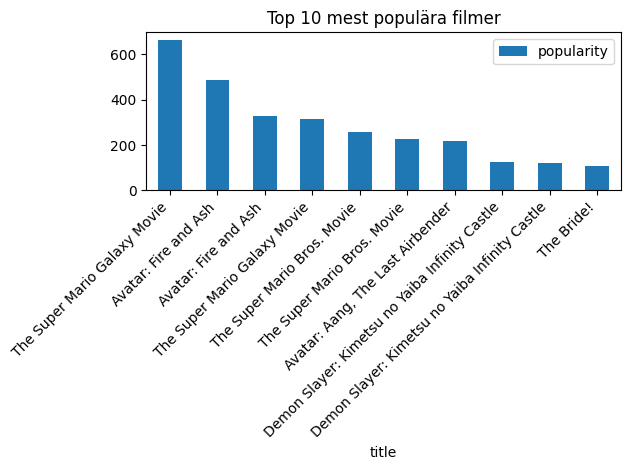

In [19]:
df.sort_values('popularity', ascending=False).head(10).plot(x='title', y='popularity', kind='bar')
plt.title('Top 10 mest populära filmer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

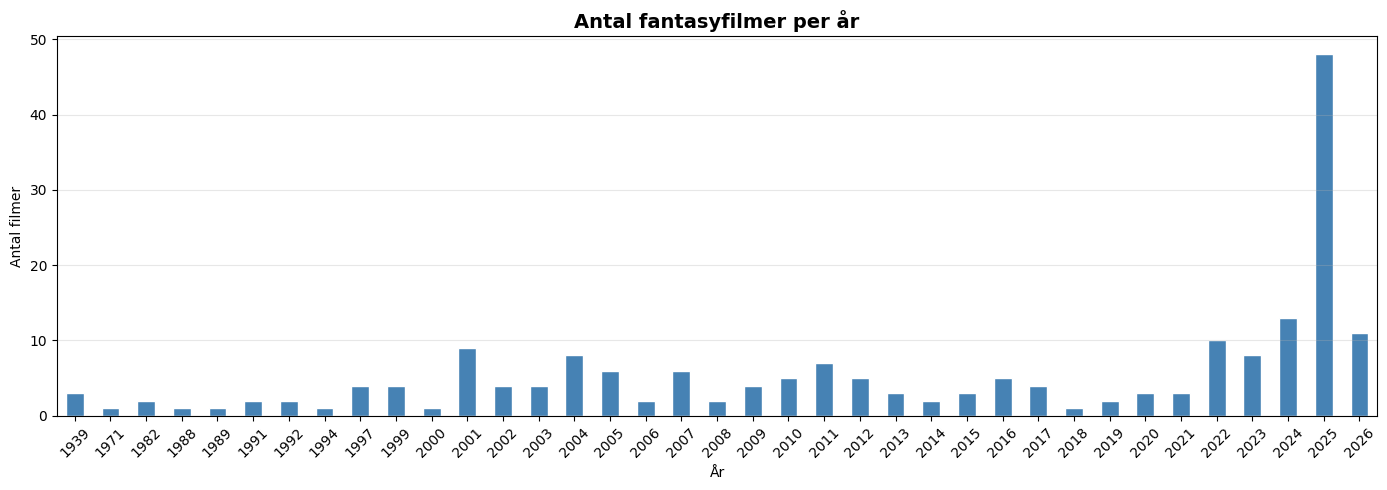

In [20]:
plt.figure(figsize=(14, 5))
df['release_year'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Antal fantasyfilmer per år', fontsize=14, fontweight='bold')
plt.xlabel('År')
plt.ylabel('Antal filmer')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Power BI

In [21]:
#df.to_csv('data/processed/movies_eda.csv', index=False) # exportera data till csv
df.to_csv('/Users/ghaliaghazal/Documents/Grupp7_Datavisualisering_DE_UX/data/processed/movies_eda.csv', index=False)

In [25]:
df["genres"].head()

0         Animation, Family, Fantasy
1              Fantasy, Drama, Crime
2         Adventure, Fantasy, Action
3         Adventure, Fantasy, Action
4    Comedy, Drama, Fantasy, Romance
Name: genres, dtype: str

In [33]:
genre_counts

Counter({'Fantasy': 1000,
         'Adventure': 415,
         'Comedy': 383,
         'Family': 365,
         'Animation': 284,
         'Action': 275,
         'Drama': 234,
         'Romance': 151,
         'Horror': 134,
         'Sci-Fi': 111,
         'Thriller': 80,
         'Crime': 18})

# Fantasy och Adventure är de vanligaste genrerna i datasetet, vilket visar att datan främst består av mer populära och breda genrer.
# Mindre genrer förekommer betydligt mindre, vilket tyder på att de är underrepresenterade i jämförelse med de dominerande kategorierna.

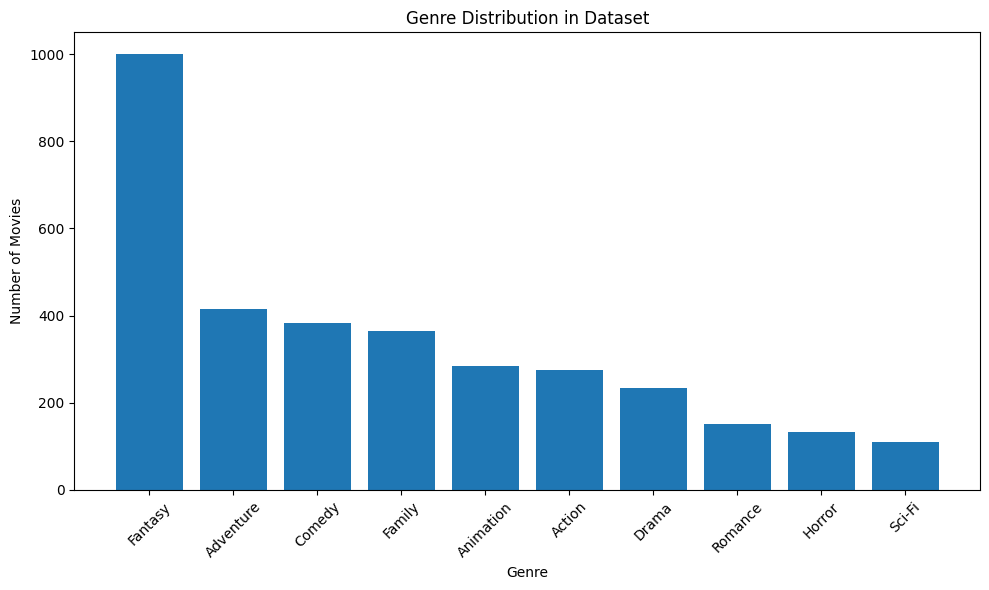

In [35]:
from collections import Counter
import matplotlib.pyplot as plt

# dela upp genres
all_genres = df["genres"].dropna().str.split(", ")

# platta ut listan
flat_genres = [g for sublist in all_genres for g in sublist]

# räkna antal per genre
genre_counts = Counter(flat_genres)

# ta top 10
top_genres = genre_counts.most_common(10)

labels = [g[0] for g in top_genres]
values = [g[1] for g in top_genres]

plt.figure(figsize=(10,6))
plt.bar(labels, values)

plt.title("Genre Distribution in Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.savefig("storytelling_genre_distribution.png", dpi=200, bbox_inches="tight")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()